In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv('../data/processed/uber.csv')

In [67]:
pd.set_option('display.max_column', None)

## Which payment methods are most commonly used?

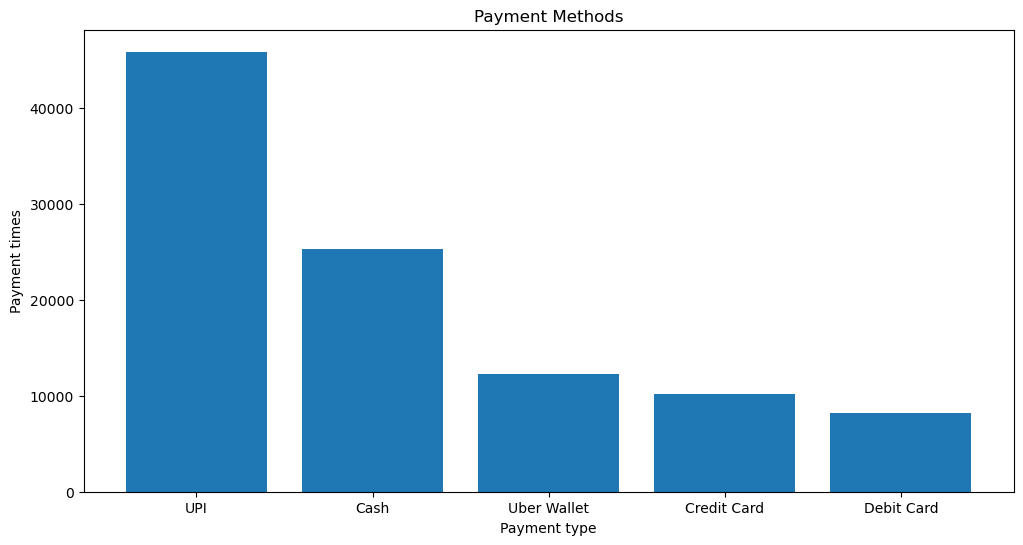

In [114]:
pay_method = df['pay_method'].value_counts().reset_index()

plt.figure(figsize=(12,6))
plt.bar(pay_method['pay_method'], pay_method['count'])
plt.title('Payment Methods') 
plt.xlabel('Payment type') 
plt.ylabel('Payment times') 

plt.show()

## Which vehicle type generates the highest revenue?

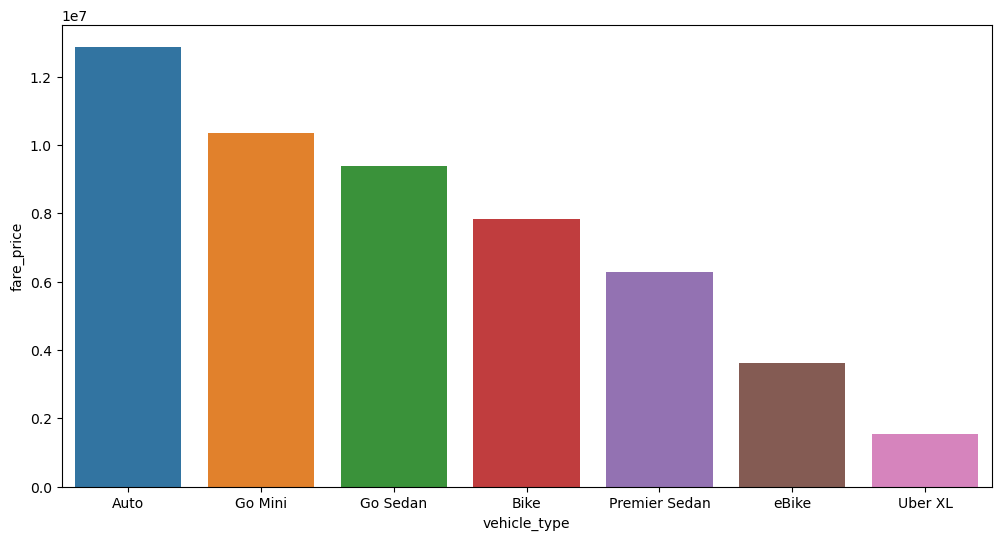

In [96]:
v_type_revenue = df.groupby('vehicle_type', as_index=False)['fare_price'].sum().sort_values(by='fare_price', ascending=False)


plt.figure(figsize=(12,6))
sns.barplot(data=v_type_revenue, x='vehicle_type', y='fare_price')

plt.show()

## How does total revenue trend over time?

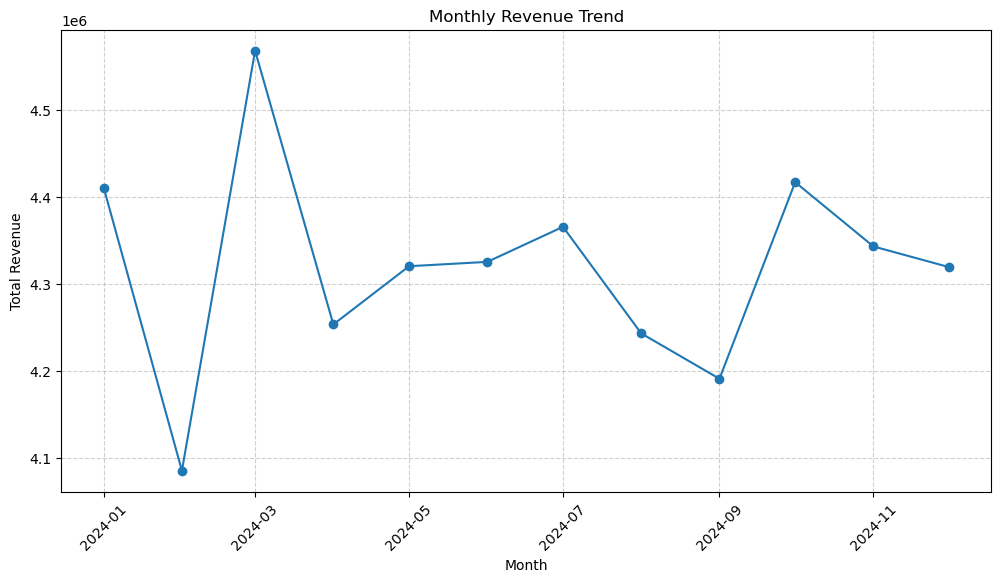

In [120]:
df['full_time'] = pd.to_datetime(df['full_time'])

monthly_revenue = df.groupby(df['full_time'].dt.to_period('M'))['fare_price'].sum().reset_index()

monthly_revenue['full_time'] = monthly_revenue['full_time'].dt.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['full_time'], monthly_revenue['fare_price'], marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


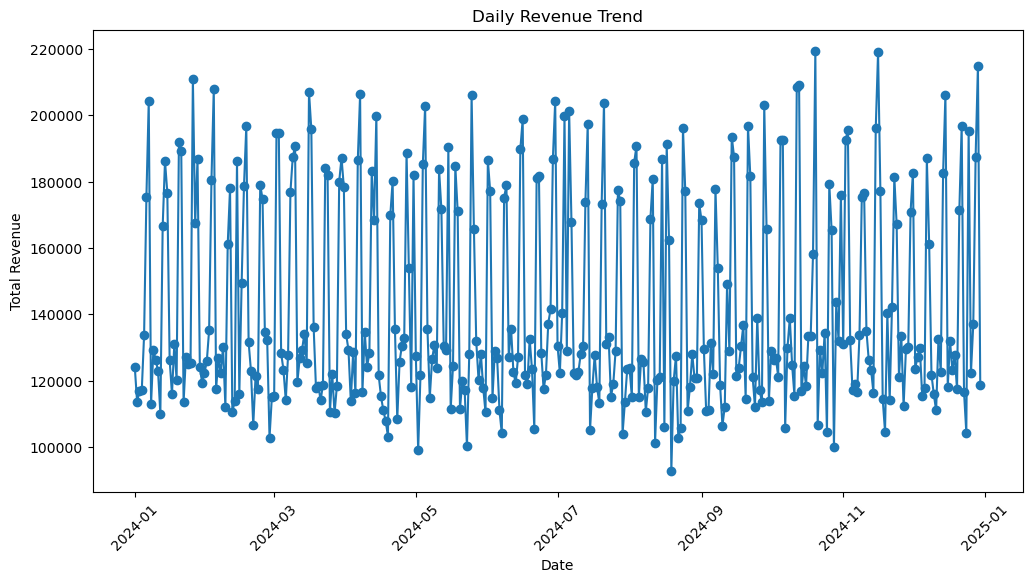

In [122]:
# daily revenue

df['full_time'] = pd.to_datetime(df['full_time'])
daily_revenue = df.groupby(df['full_time'].dt.date)['fare_price'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(daily_revenue['full_time'], daily_revenue['fare_price'], marker='o')

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()